In [3]:
from warnings import filterwarnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split
import pandas as pd

sns.set(style='darkgrid')
filterwarnings('ignore')

In [4]:
X = load_npz('x.npz')
y = np.load('y.npy')
y = (y == 1) * 1 + (y == 0) * (-1)

Разделим на обучающую, валидационную и тестовую выборки (оставьте `random_state=1337` для воспроизводимости).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=1337)

X_train.shape, X_valid.shape, X_test.shape

((18825, 169), (2354, 169), (2353, 169))

---

## Задание 1. Базовый градиентный бустинг (4 балла)

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='plum'>**вопросы**</font> должен быть <font color='plum'>**ответ**</font>. В заданиях есть референсы для параметров, которые нужно сделать, на случай, если объяснение из ноутбука непонятно, тогда советуем обратиться к соответствующей документации

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Обязательные параметры:
 — `base_model_class` — класс базовой модели нашего бустинга
 — `base_model_params` — словарь с гиперпараметрами для базовой модели
 — `n_estimators` — какое количество базовых моделей нужно обучить
 — `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`). После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах). После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

После всего цикла обучения надо нарисовать график (если `plot=True`).

#### `partial_fit`

В `partial_fit` приходит обучающая выборка, на которую обучается новая базовая модель

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

#### `plot_history`

В `plot_history` приходит любая выборка, для которой последовательно считаются значения функции потерь и/или любой метрики, которую вы хотите посчитать, путем последовательного применения базовых моделей. Можно делать сразу во время обучения, можно делать иначе

In [6]:
# %pip install -U ipython

In [7]:
# %load_ext autoreload

In [8]:
# %autoreload 2

from boosting import Boosting

### Проверка кода

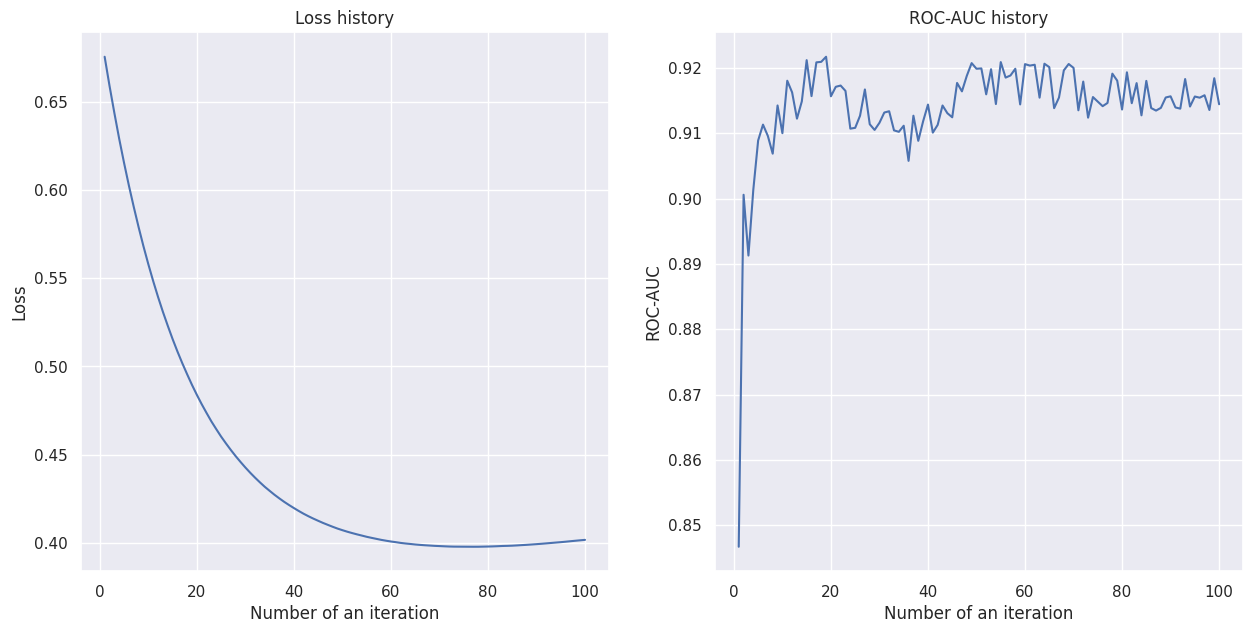

Train ROC-AUC 0.9998
Valid ROC-AUC 0.9145
Test ROC-AUC 0.9113


In [9]:
boosting = Boosting(n_estimators=100)

boosting.fit(X_train, y_train)
boosting.plot_history(X_valid, y_valid)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

---

## Задание 2. Имплементация гиперпараметров (2.5 балла + 3.5 бонус)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации безотносительно базовой модели. В этом пункте предлагается имплементировать часть из них. При необходимости можете обратиться к реализациям в вашей любимой библиотеке, там могут быть дополнительные пояснения и/или ссылки на оригинальные статьи

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону, для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**дефолтные параметры не подойдут**</font>, они скорее для референса. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотрить именно на них

### 2.1. Борьба с переобучением (0.5 балла)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете делать для трейна, нужно будет повторить на валидации

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| <td colspan=3>`early_stopping_rounds`, `eval_set` |

Добавьте параметры:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `X_val`, `y_val` или `eval_set: Tuple[np.ndarray] | None = None` — валидацонная выборка, на которой будем проверять переобучение

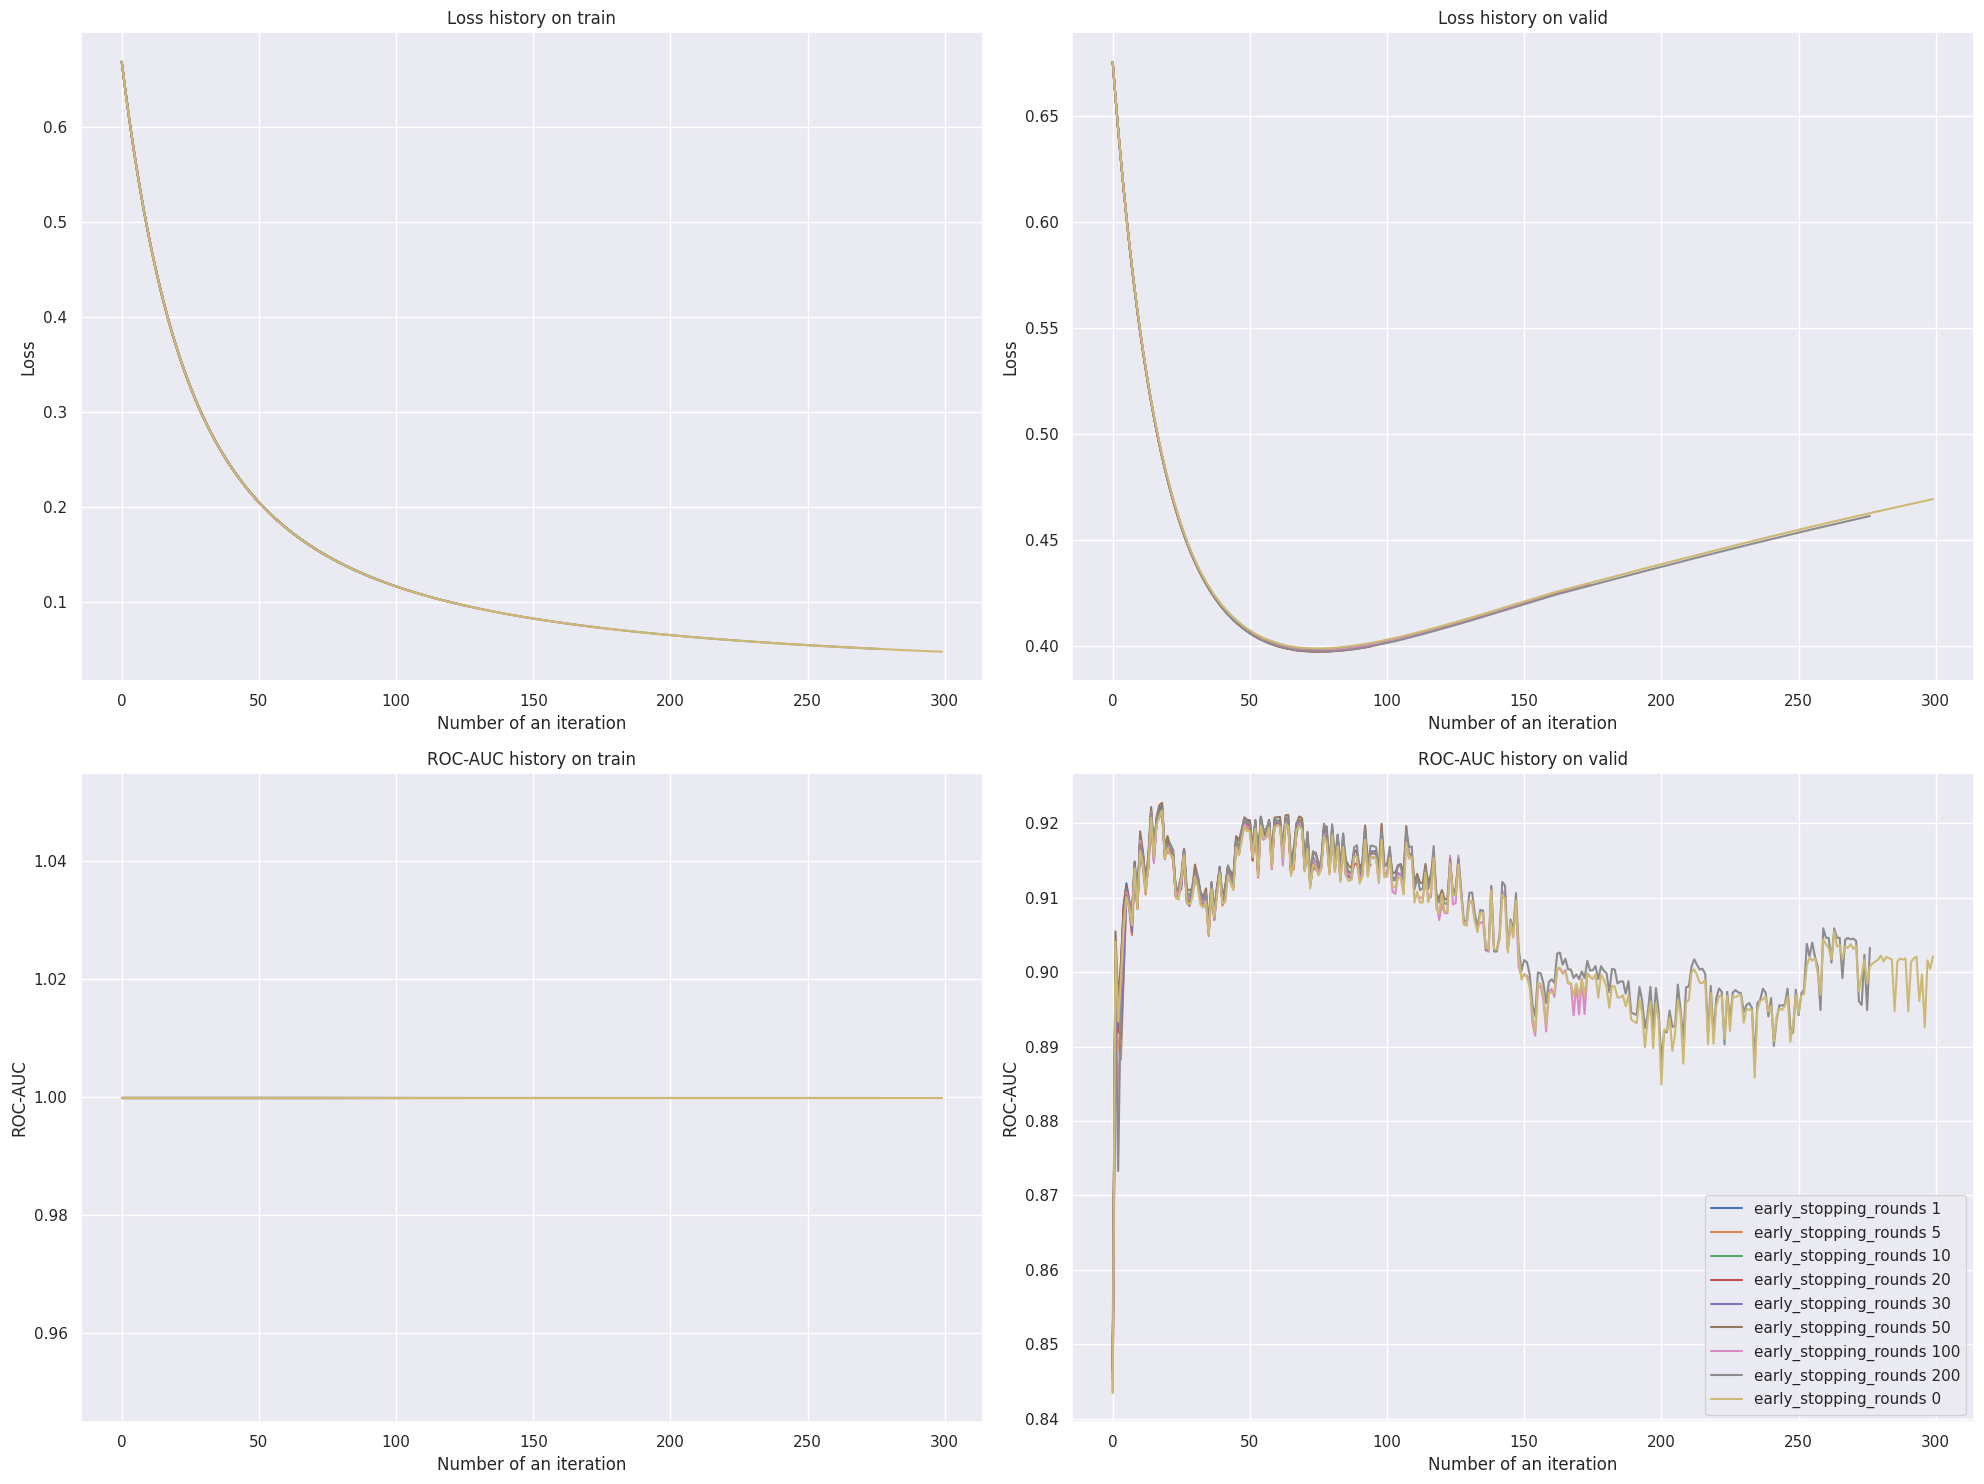

In [10]:
early_stopping_num = [1, 5, 10, 20, 30, 50, 100, 200, 0]

fig, ax = plt.subplots(figsize=(20, 15), ncols=2, nrows=2)
for num in early_stopping_num:
    boosting = Boosting(n_estimators=300, early_stopping_rounds=num)
    boosting.fit(X_train, y_train, X_valid, y_valid)

    ax[0][0].plot(range(len(boosting.history['train_loss'])), boosting.history['train_loss'], label=f'early_stopping_rounds {num}')
    ax[0][1].plot(range(len(boosting.history['val_loss'])), boosting.history['val_loss'], label=f'early_stopping_rounds {num}')
    ax[0][0].set_xlabel('Number of an iteration')
    ax[0][0].set_ylabel('Loss')
    ax[0][0].set_title('Loss history on train')
    ax[0][1].set_xlabel('Number of an iteration')
    ax[0][1].set_ylabel('Loss')
    ax[0][1].set_title('Loss history on valid')

    ax[1][0].plot(range(len(boosting.history['train_aucroc'])), boosting.history['train_aucroc'], label=f'early_stopping_rounds {num}')
    ax[1][1].plot(range(len(boosting.history['val_aucroc'])), boosting.history['val_aucroc'], label=f'early_stopping_rounds {num}')
    ax[1][0].set_xlabel('Number of an iteration')
    ax[1][0].set_ylabel('ROC-AUC')
    ax[1][0].set_title('ROC-AUC history on train')
    ax[1][1].set_xlabel('Number of an iteration')
    ax[1][1].set_ylabel('ROC-AUC')
    ax[1][1].set_title('ROC-AUC history on valid')
plt.legend()
plt.tight_layout()
plt.show()

В данном случае параметр особо не помогает в борьбе с переобучением, динамика лоссов примерно одна при разных значениях.

### Бонус. Бустинг линейных моделей (0.5 балла)

**<font color='plum'>Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?</font>

<font color='plum'>**Ответ:** при ансамблировании линейных моделей по идее получается одна линейная модель (потому что суммируются n линейных моделей и схлопываются в одну). Однако данный метод отличается процессом обучения; он обучает новые модели на сдвиги, когда, например, в логреге обучение идет изначальной модели на ответы. Он может быть полезен, так как каждая базовая модель в ГБ простая, не требует большого количества времени на обучение, из-за чего бустинг может работать быстрее.  </font>

Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='lightblue'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `XGBClassifier(booster="gblinear")` | — | — |

In [11]:
y_train_xgb = (y_train == 1) * 1
y_valid_xgb = (y_valid == 1) * 1

In [12]:
from xgboost import XGBClassifier
import time
start_time_xgb = time.time()
xgb_cl_lin = XGBClassifier(booster='gblinear',
              objective='binary:logistic',
              eval_metric='logloss',
              n_estimators=200)
xgb_cl_lin.fit(X_train, y_train_xgb, eval_set=[(X_valid, y_valid_xgb), (X_train, y_train_xgb)], verbose=False)
xgb_time = time.time() - start_time_xgb

In [13]:
xgb_loss_train = xgb_cl_lin.evals_result()['validation_1']['logloss']
xgb_loss_val = xgb_cl_lin.evals_result()['validation_0']['logloss']

Теперь возьмите `sklearn.linear_model.SGDClassifier` иобучите на тех же данных. Не забудьте вытащить историю функции потерь

In [14]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
start_time_sgd = time.time()
sgd_classifier = SGDClassifier(loss='log_loss', max_iter=1)
sgd_loss_train, sgd_loss_val = [], []
for i in range(200):
    sgd_classifier.partial_fit(X_train, y_train, np.unique(y_train))
    prob_train = sgd_classifier.predict_proba(X_train)
    prob_val = sgd_classifier.predict_proba(X_valid)
    loss_train = log_loss(y_train, prob_train)
    loss_val = log_loss(y_valid, prob_val)
    sgd_loss_train.append(loss_train)
    sgd_loss_val.append(loss_val)
sgd_time = time.time() - start_time_sgd

Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

In [15]:
print(f'Время обучения XGBoost: {xgb_time}')
print(f'Время обучения SGDClassifier: {sgd_time}')

Время обучения XGBoost: 1.7386538982391357
Время обучения SGDClassifier: 3.7371978759765625


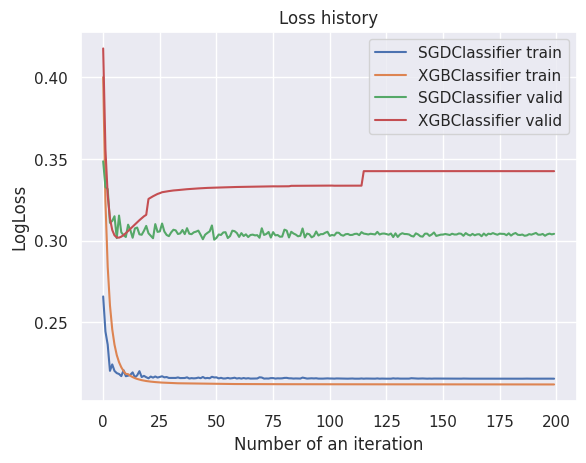

In [16]:
iters = len(sgd_loss_train)
plt.plot(range(iters), sgd_loss_train, label='SGDClassifier train')
plt.plot(range(iters), xgb_loss_train, label='XGBClassifier train')
plt.plot(range(iters), sgd_loss_val, label='SGDClassifier valid')
plt.plot(range(iters), xgb_loss_val, label='XGBClassifier valid')
plt.title('Loss history')
plt.xlabel('Number of an iteration')
plt.ylabel('LogLoss')
plt.legend()
plt.show()

<font color='plum'>**Вопрос:** Какой вывод вы можете сделать?</font>

<font color='plum'>**Ответ:** XGBoost значительно быстрее SGDClassifier в данной задаче, как я предположила, возможно из-за простоты базовых моделей в бустинге.
Оба метода демонстрируют быстрое улучшение функции потерь на начальных этапах обучения как на тренировочных, так и на валидационных данных. То есть сходимость примерно одинаковая по времени. По стабильности: бустинг идет чуть более гладко, у SGD видны осцилляции. Однако на валидации у бустинга за счет увеличения количества моделей сначала падает лосс, так как снижается смещение, но при этом растет разброс, поэтому затем на валидации ошибка вырастает, и потом уже выходит на асимптоту. /font>

### 2.2. Бутстрап (0.5 балла)
Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `subsample`, — | `subsample`, `bagging`| `subsample`, `bootstrap_type`|

Вам нужно реализовать параметры:
- `subsample: float | int = 1.0` — доля или число объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float | int = 1.0` — веса объектов, которые попадают в выборку. Соответствует бутстрапу типа `Bayesian`. Каждый объект имеет определенный вес $t$, на который впоследствии домножается по формуле $w = (-\log(X))^t$, где $X \sim {U[0, 1]}$, после чего попадает в выборку. Таким образом можно сделать симуляцию повторений
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<font color='plum'>**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?</font>

<font color='plum'>**Ответ:** бутстрап может увеличить смещение, так как модели обучаются на менее полных данных, но разброс снижается, поскольку каждая модель теперь будет обучаться на чуть разном наборе данных, снижается корреляция моделей. Это актуально в бустинге, так как в нем по мере добавления моделей снижается смещение и увеличивается разброс. В целом бутстрап может повысить обучающую способность модели, сделать ее менее склонной к переобучению. </font>

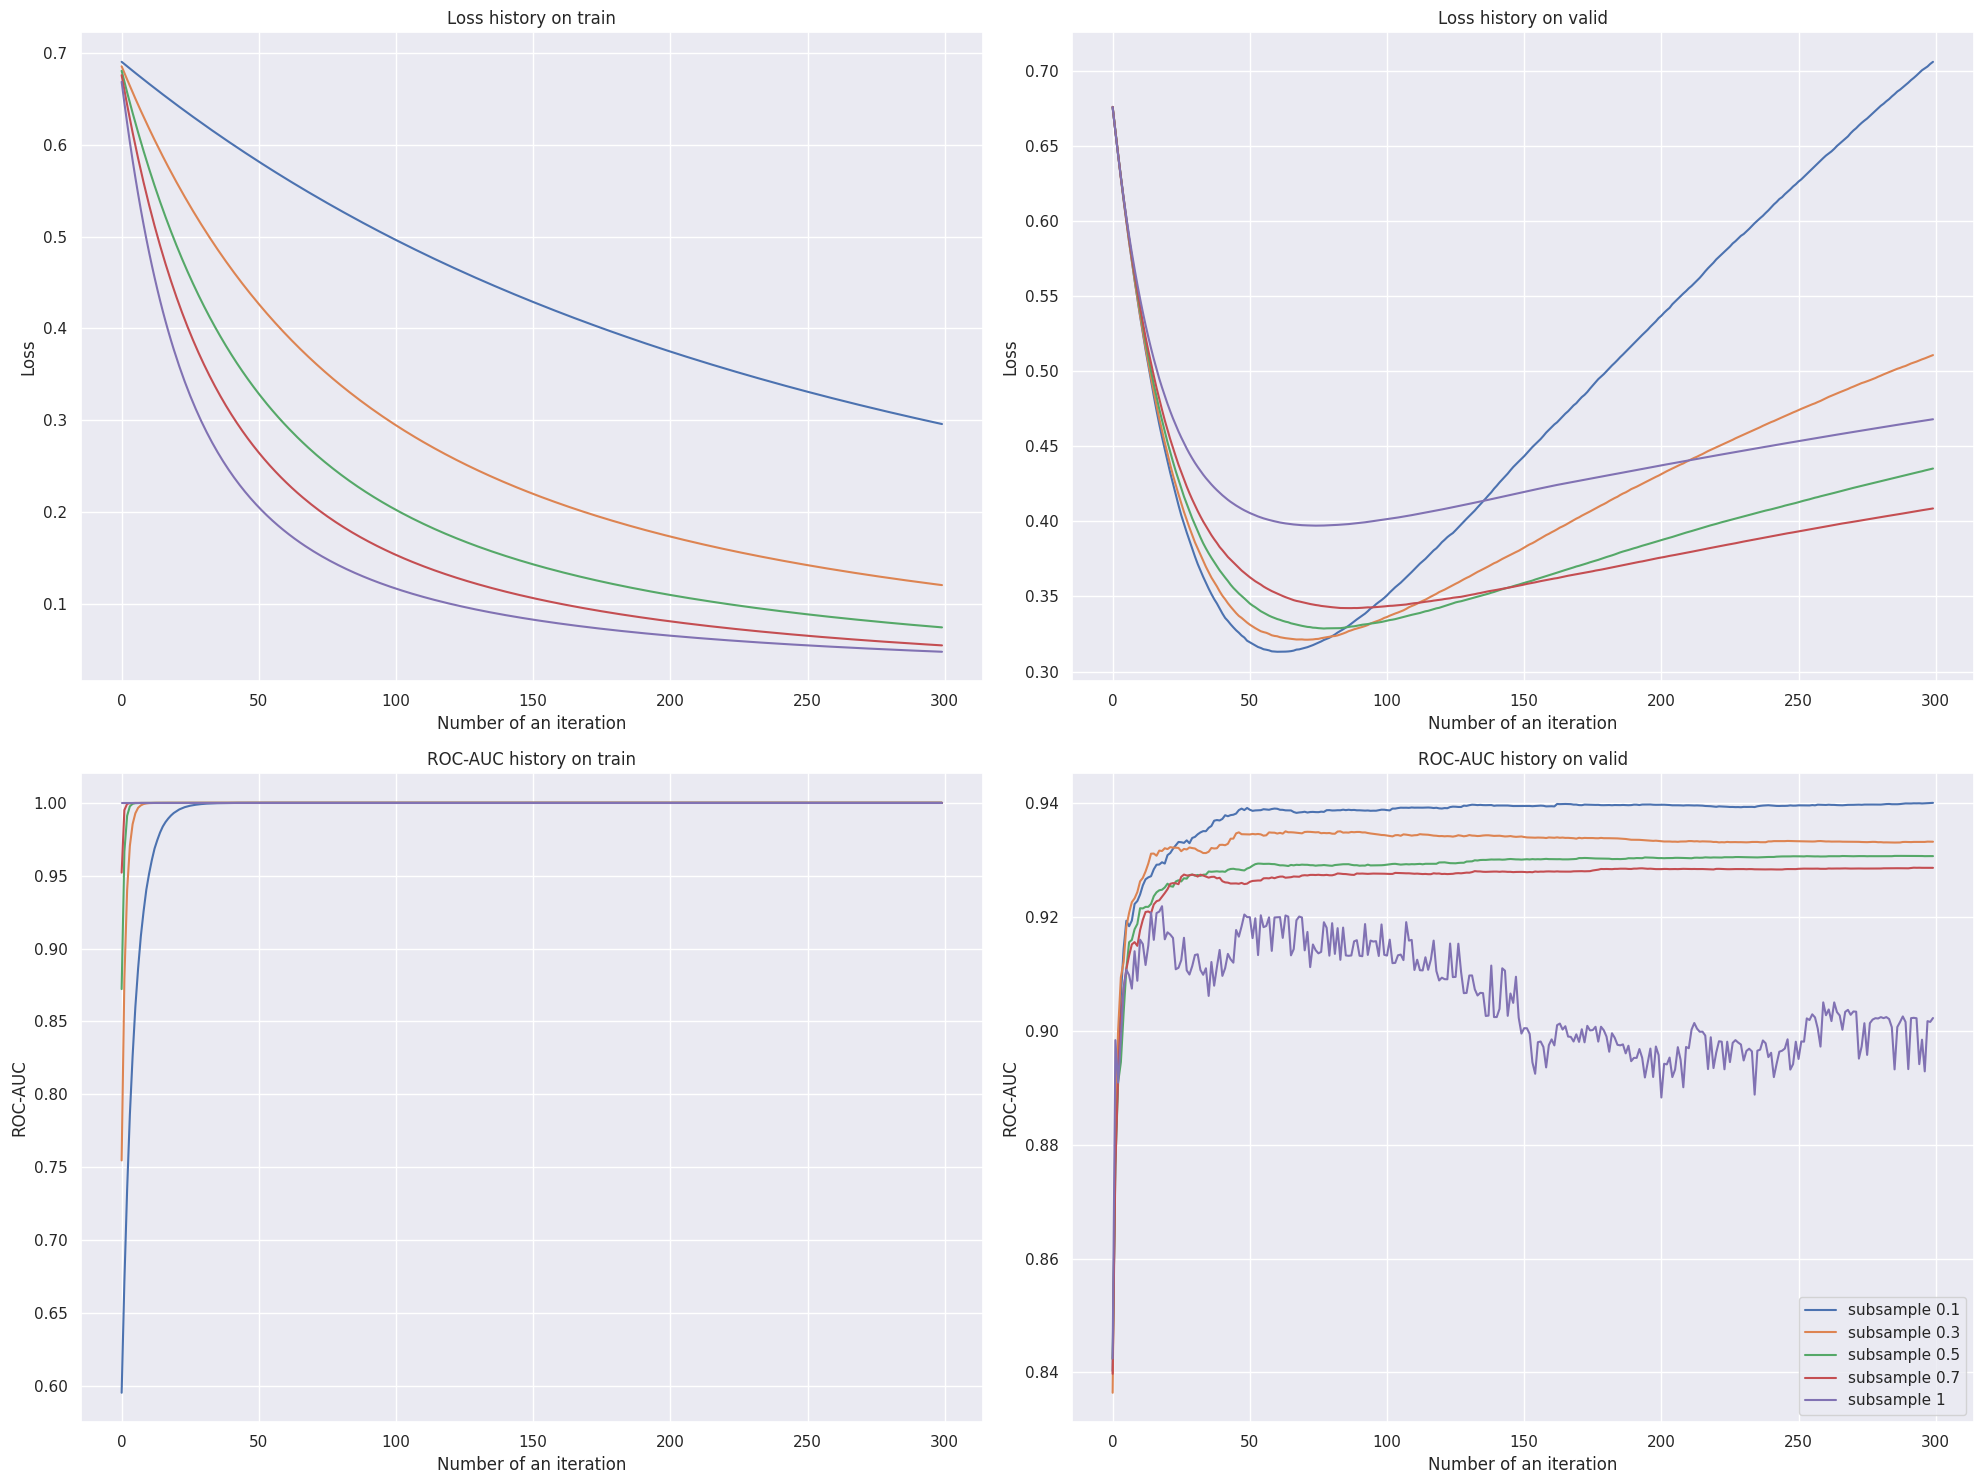

In [17]:
# Bernoulli
subsamples = [0.1, 0.3, 0.5, 0.7, 1]

fig, ax = plt.subplots(figsize=(20, 15), ncols=2, nrows=2)
for num in subsamples:
    boosting = Boosting(n_estimators=300, bootstrap_type='Bernoulli', subsample=num)
    boosting.fit(X_train, y_train, X_valid, y_valid)

    ax[0][0].plot(range(len(boosting.history['train_loss'])), boosting.history['train_loss'], label=f'subsample {num}')
    ax[0][1].plot(range(len(boosting.history['val_loss'])), boosting.history['val_loss'], label=f'subsample {num}')
    ax[0][0].set_xlabel('Number of an iteration')
    ax[0][0].set_ylabel('Loss')
    ax[0][0].set_title('Loss history on train')
    ax[0][1].set_xlabel('Number of an iteration')
    ax[0][1].set_ylabel('Loss')
    ax[0][1].set_title('Loss history on valid')

    ax[1][0].plot(range(len(boosting.history['train_aucroc'])), boosting.history['train_aucroc'], label=f'subsample {num}')
    ax[1][1].plot(range(len(boosting.history['val_aucroc'])), boosting.history['val_aucroc'], label=f'subsample {num}')
    ax[1][0].set_xlabel('Number of an iteration')
    ax[1][0].set_ylabel('ROC-AUC')
    ax[1][0].set_title('ROC-AUC history on train')
    ax[1][1].set_xlabel('Number of an iteration')
    ax[1][1].set_ylabel('ROC-AUC')
    ax[1][1].set_title('ROC-AUC history on valid')
plt.legend()
plt.tight_layout()
plt.show()

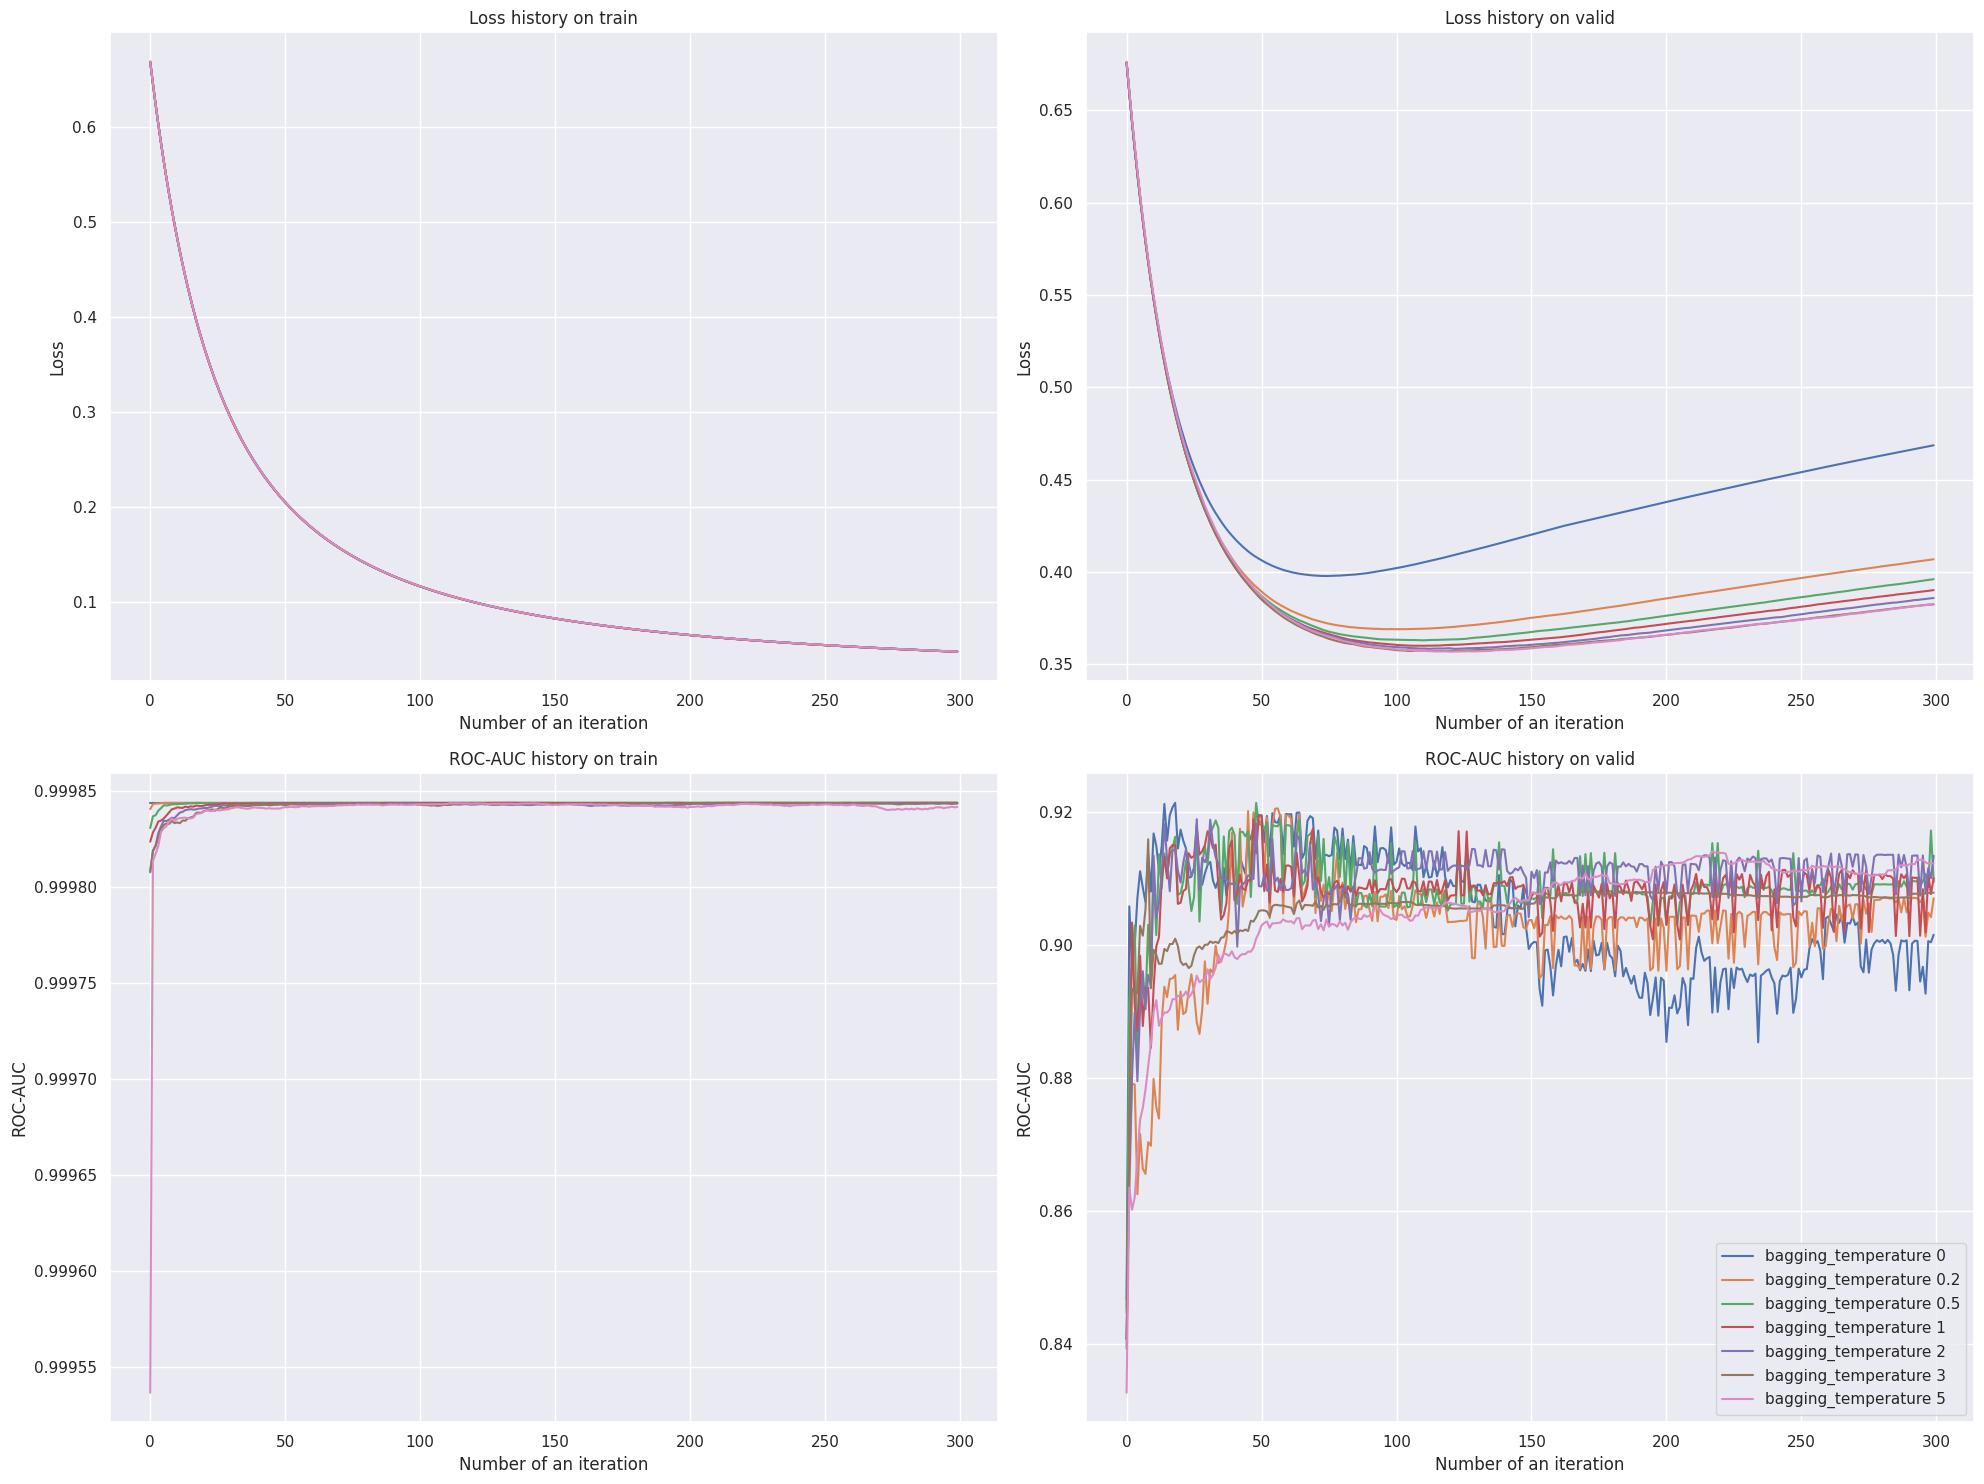

In [18]:
# Bayesian
temperatures = [0, 0.2, 0.5, 1, 2, 3, 5]

fig, ax = plt.subplots(figsize=(20, 15), ncols=2, nrows=2)
for num in temperatures:
    boosting = Boosting(n_estimators=300, bootstrap_type='Bayesian', bagging_temperature=num)
    boosting.fit(X_train, y_train, X_valid, y_valid)

    ax[0][0].plot(range(len(boosting.history['train_loss'])), boosting.history['train_loss'], label=f'bagging_temperature {num}')
    ax[0][1].plot(range(len(boosting.history['val_loss'])), boosting.history['val_loss'], label=f'bagging_temperature {num}')
    ax[0][0].set_xlabel('Number of an iteration')
    ax[0][0].set_ylabel('Loss')
    ax[0][0].set_title('Loss history on train')
    ax[0][1].set_xlabel('Number of an iteration')
    ax[0][1].set_ylabel('Loss')
    ax[0][1].set_title('Loss history on valid')

    ax[1][0].plot(range(len(boosting.history['train_aucroc'])), boosting.history['train_aucroc'], label=f'bagging_temperature {num}')
    ax[1][1].plot(range(len(boosting.history['val_aucroc'])), boosting.history['val_aucroc'], label=f'bagging_temperature {num}')
    ax[1][0].set_xlabel('Number of an iteration')
    ax[1][0].set_ylabel('ROC-AUC')
    ax[1][0].set_title('ROC-AUC history on train')
    ax[1][1].set_xlabel('Number of an iteration')
    ax[1][1].set_ylabel('ROC-AUC')
    ax[1][1].set_title('ROC-AUC history on valid')
plt.legend()
plt.tight_layout()
plt.show()

Судя по графикам, при использовании subsample снижается ошибка на валидации, и растет ROC-AUC, на трейне происходит ровно наоборот. Bayesian бутстрап не показывает настолько сильного улучшения, но все равно при хорошо подобранном параметре можно улучшить обучающую способность модели.

### 2.3. Работа с признаками (1 балл)

1. Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать `rsm`

2. С другой стороны, вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет. Для этого существует множество алгоритмов, мы предлагаем сделать два наиболее простых:

- $\text{Uniform}$. Значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- $\text{Quantile}$. Тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

| <font color='lightblue'>XGBoost</font> | <font color='lightgreen'>LightGBM</font> | <font color='palegoldenrod'>CatBoost</font> |
| --- | --- | --- |
| `colsample_bytree`, `tree_method` | `colsample_bytree`, `max_bin`| `rsm`, `quantize(...)`|

Нужно добавить параметры:
- `rsm: float | int = 1.0` — доля или число признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

<font color='plum'>**Вопрос**: как квантизация поможет в обработке выбросов и нанов?</font>

<font color='plum'>**Ответ**: Оба метода могут помочь в обработке выбросов, так как все экстремальные значения будут помещены в крайние интервалы. Однако uniform зависит от минимальных и максимальных значений данных для определения интервалов. Сильно отличающиеся выбросы могут сильно расширить этот диапазон, и все обычные наблюдения будут в нескольких близко расположенных бинах, многие бины могут не содержать наблюдений вовсе, а крайние будут содержать выбросы. Quantile более эффективен в обработке выбросов, так как он гарантирует, что выбросы не будут влиять на распределение в каждом бине, и выбросы окажутся либо в самом высоком, либо в самом низком бине, рапсределение будет более менее равномерное. Наны квантизация не помогает обрабатывать. </font>

<font color='plum'>**Вопрос**: можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?</font>

<font color='plum'>**Ответ**: в целом можно заполнить наны числом, если их не очень много. Но если заполнить все выбросы одним рандомным числом, то скорее это будет плохо, так как не учитывается масштаб, распределение каждого признака. Поэтому лучше с умом выбирать это число, и разное для каждого признака, иначе можно искуственно сместить распределение данных. Если пропущенных значений много, то лучше более основательно подойти к обработке выбросов, возможно, стоит даже удалить какие то наблюдения/признаки. Но заполнение нанов каким-то экстремальным числом может быть полезно, если нужно сохранять информацию о том, что здесь расположен нан. Однако это может создать проблемы в алгоритмах, которые чувствительны к масштабу данных или к распределению значений. </font>

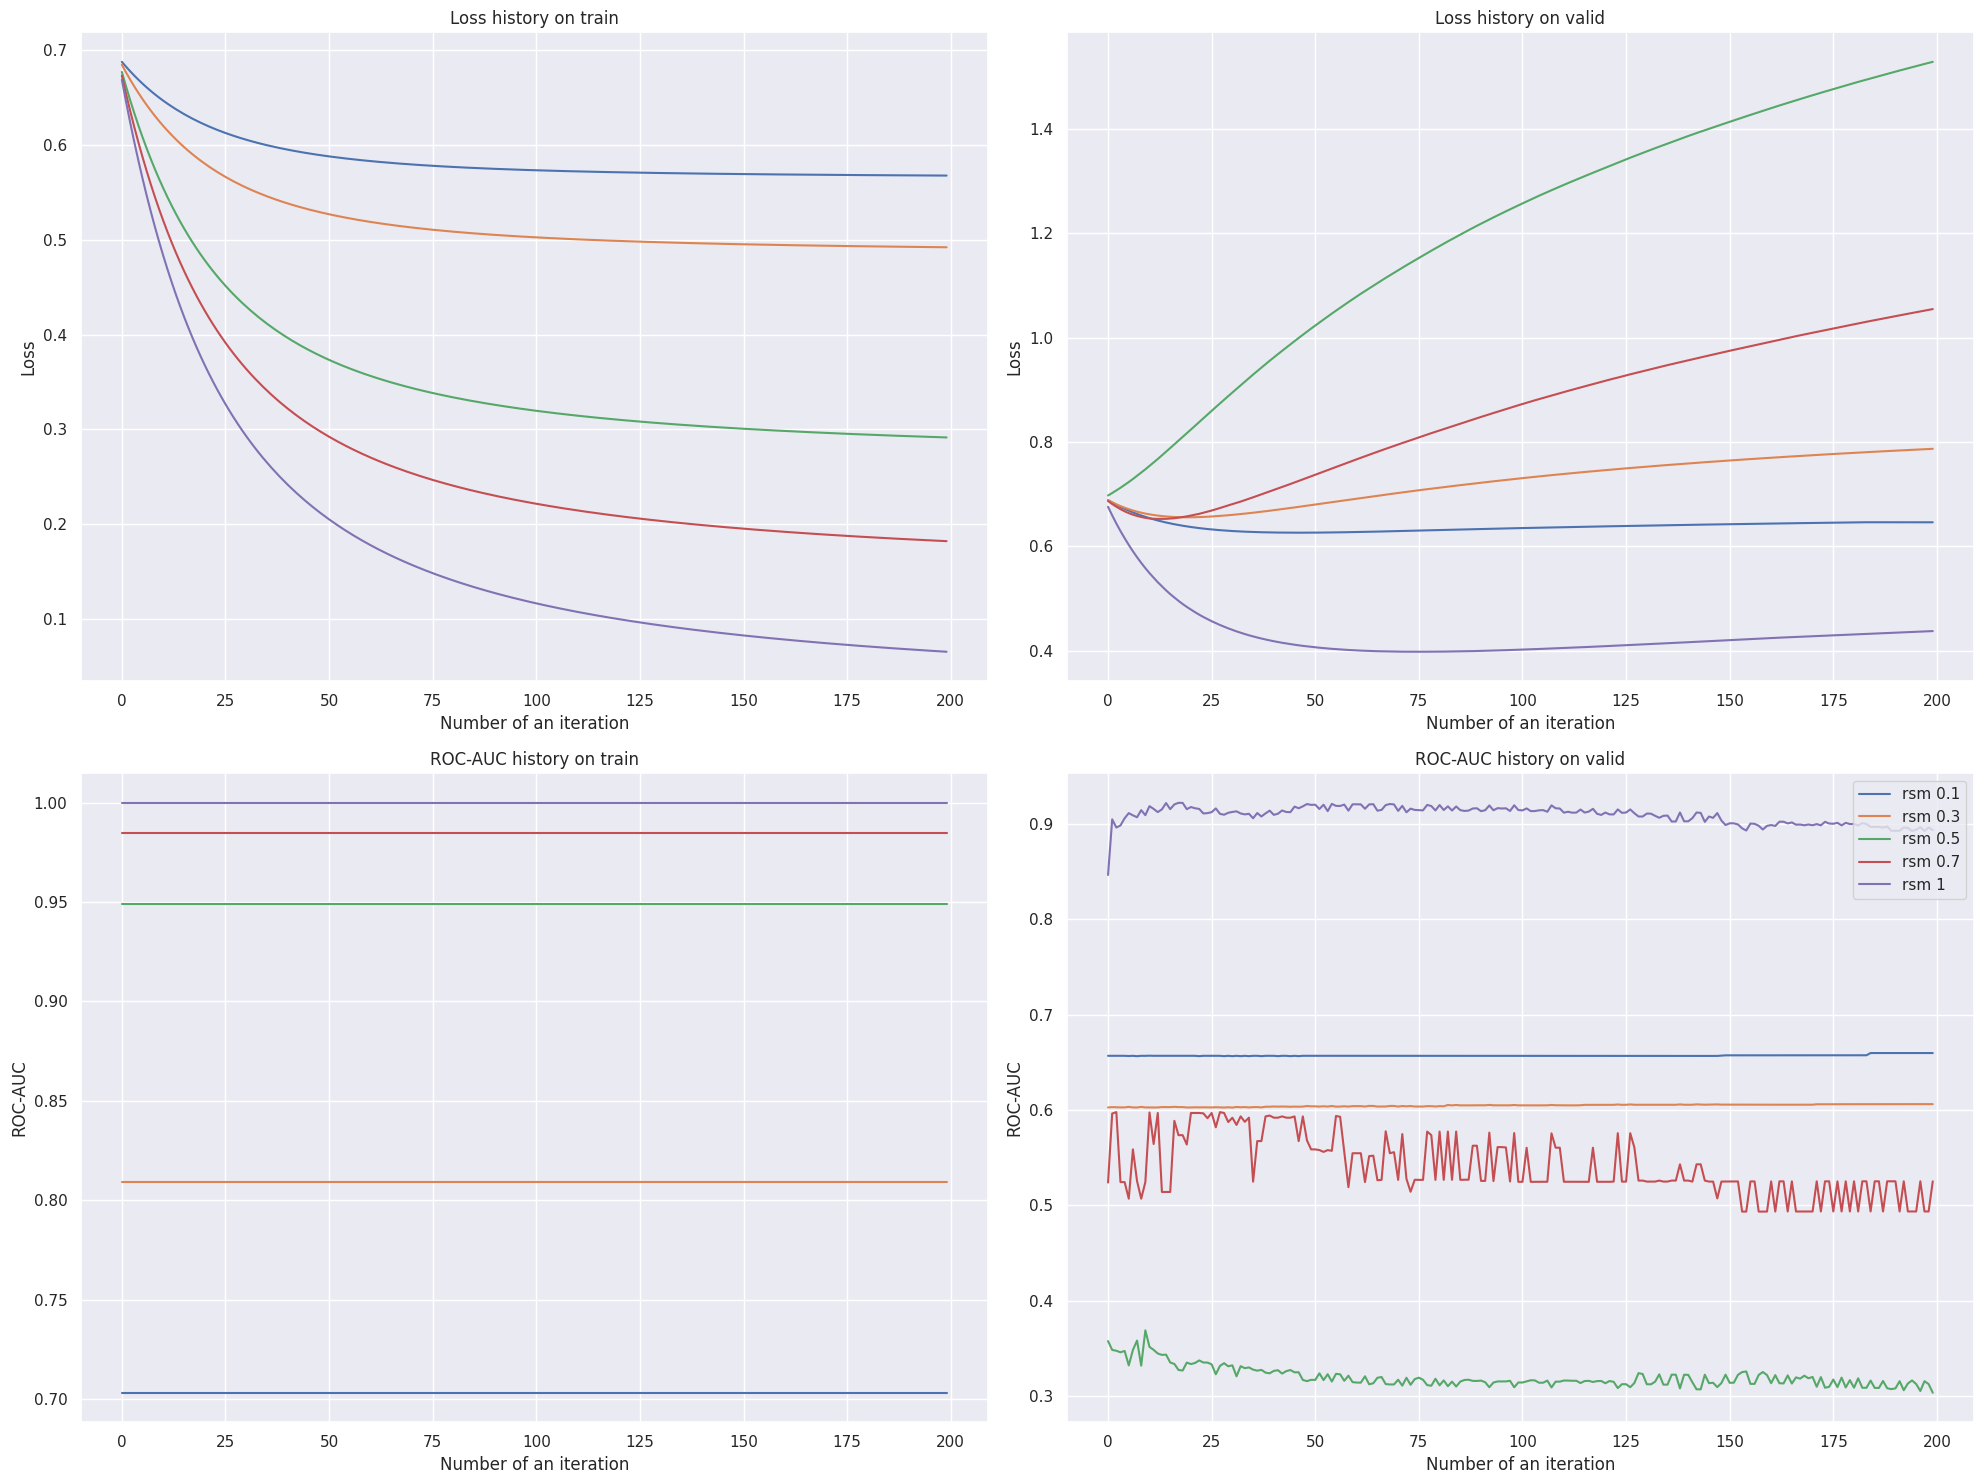

In [19]:
# rsm
rsms = [0.1, 0.3, 0.5, 0.7, 1]
fig, ax = plt.subplots(figsize=(20, 15), ncols=2, nrows=2)
for num in rsms:
    boosting = Boosting(n_estimators=200, rsm=num)
    boosting.fit(X_train, y_train, X_valid, y_valid)

    ax[0][0].plot(range(len(boosting.history['train_loss'])), boosting.history['train_loss'], label=f'rsm {num}')
    ax[0][1].plot(range(len(boosting.history['val_loss'])), boosting.history['val_loss'], label=f'rsm {num}')
    ax[0][0].set_xlabel('Number of an iteration')
    ax[0][0].set_ylabel('Loss')
    ax[0][0].set_title('Loss history on train')
    ax[0][1].set_xlabel('Number of an iteration')
    ax[0][1].set_ylabel('Loss')
    ax[0][1].set_title('Loss history on valid')

    ax[1][0].plot(range(len(boosting.history['train_aucroc'])), boosting.history['train_aucroc'], label=f'rsm {num}')
    ax[1][1].plot(range(len(boosting.history['val_aucroc'])), boosting.history['val_aucroc'], label=f'rsm {num}')
    ax[1][0].set_xlabel('Number of an iteration')
    ax[1][0].set_ylabel('ROC-AUC')
    ax[1][0].set_title('ROC-AUC history on train')
    ax[1][1].set_xlabel('Number of an iteration')
    ax[1][1].set_ylabel('ROC-AUC')
    ax[1][1].set_title('ROC-AUC history on valid')
plt.legend()
plt.tight_layout()
plt.show()

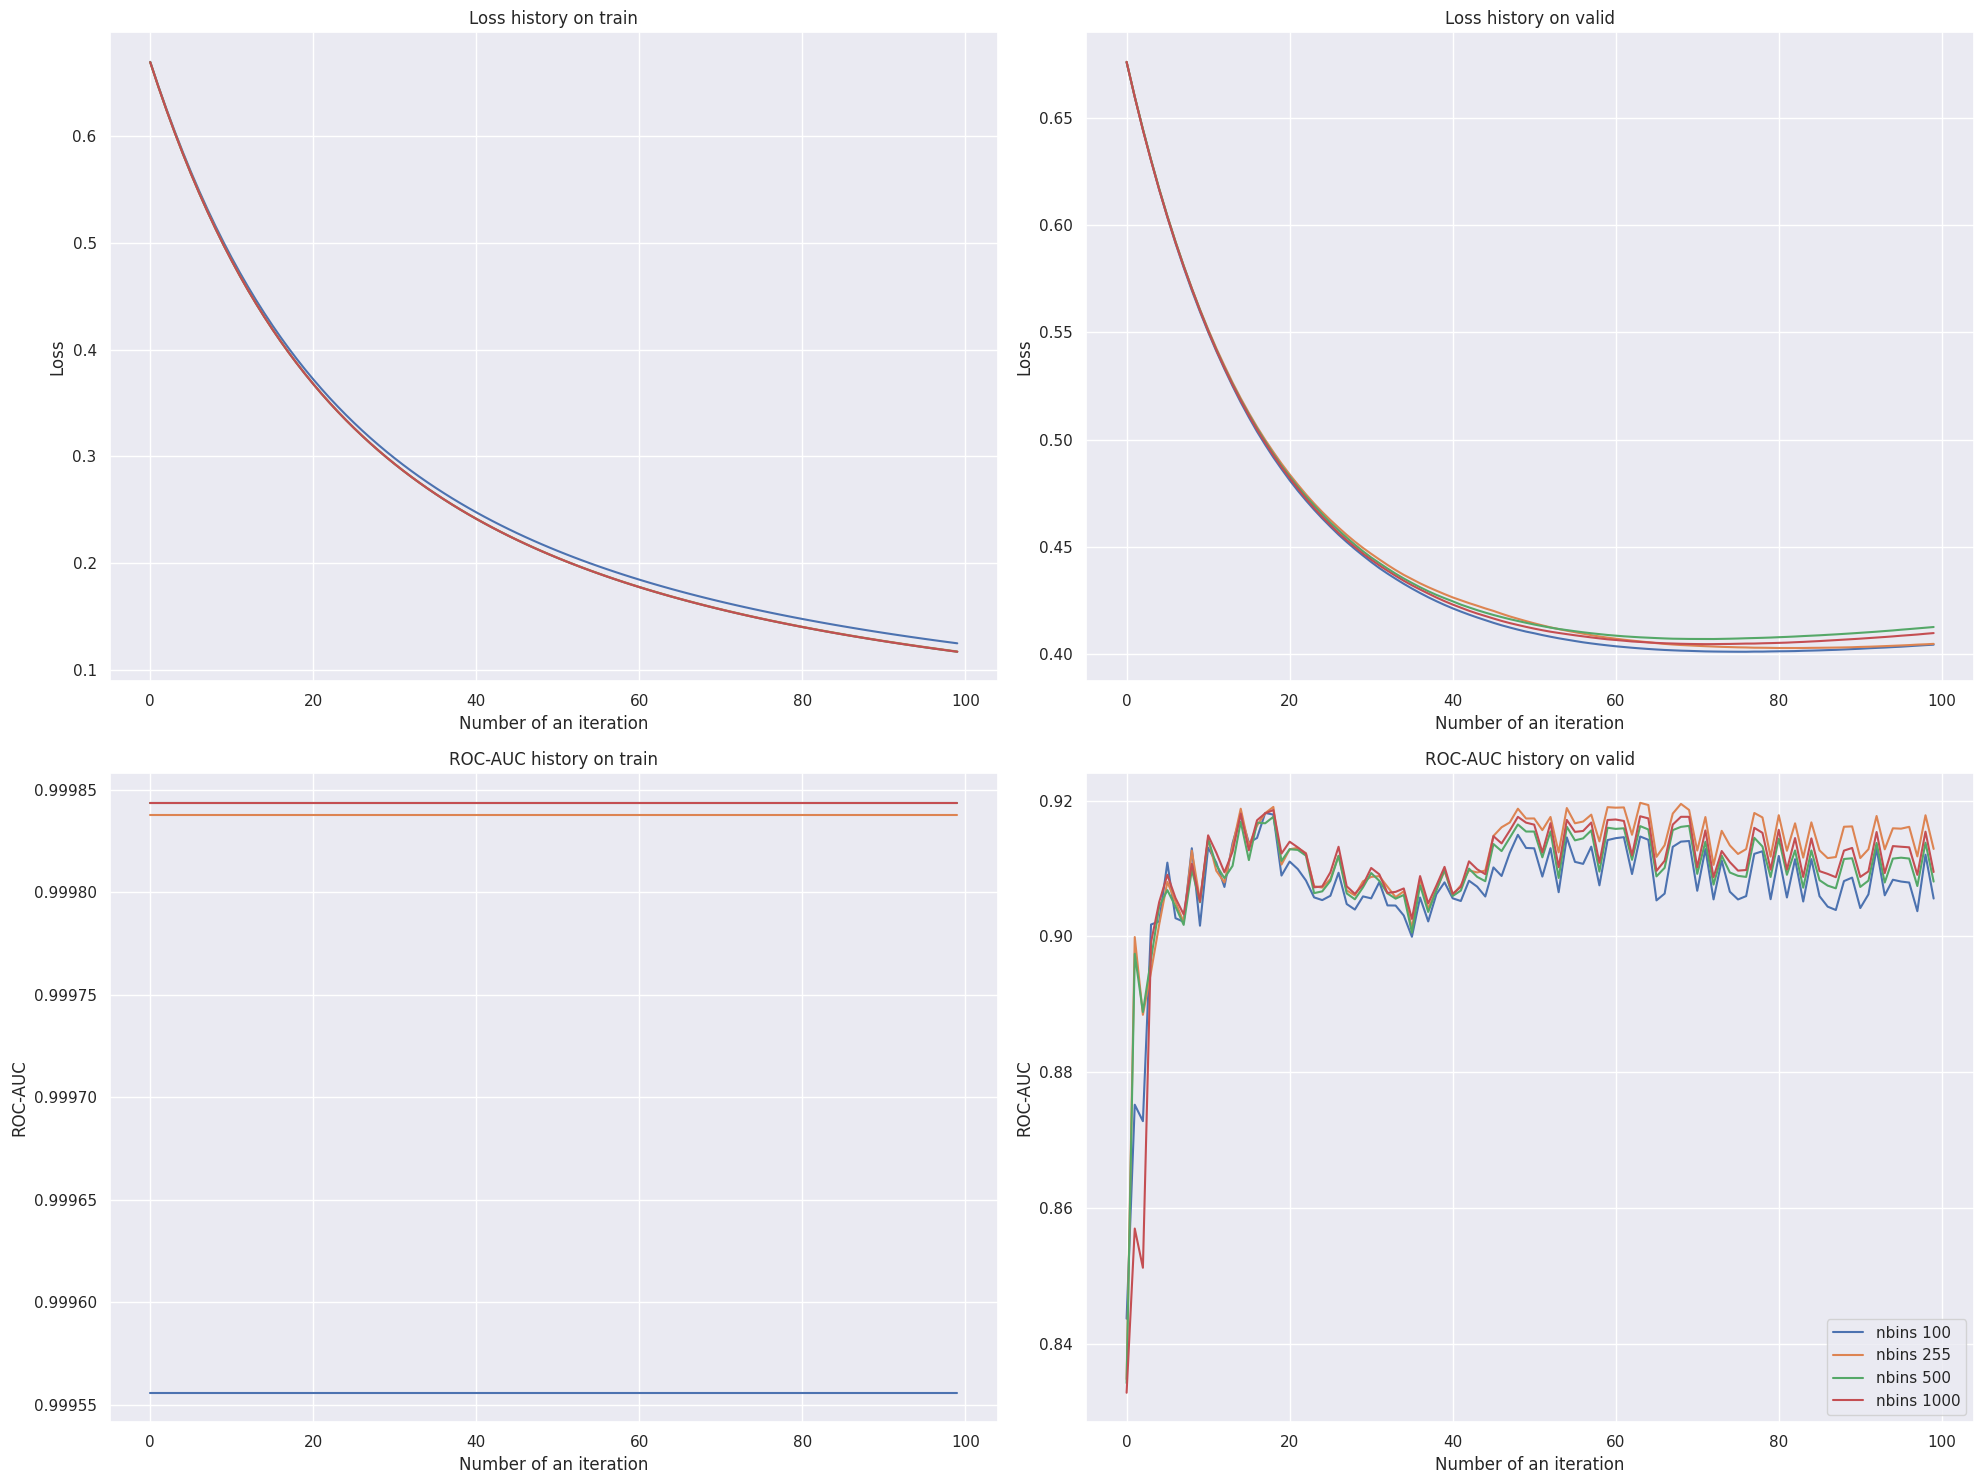

In [20]:
# uniform
nbins = [100, 255, 500, 1000]
fig, ax = plt.subplots(figsize=(20, 15), ncols=2, nrows=2)
for num in nbins:
    boosting = Boosting(n_estimators=100, quantization_type = 'Uniform', nbins=num)
    boosting.fit(X_train, y_train, X_valid, y_valid)

    ax[0][0].plot(range(len(boosting.history['train_loss'])), boosting.history['train_loss'], label=f'nbins {num}')
    ax[0][1].plot(range(len(boosting.history['val_loss'])), boosting.history['val_loss'], label=f'nbins {num}')
    ax[0][0].set_xlabel('Number of an iteration')
    ax[0][0].set_ylabel('Loss')
    ax[0][0].set_title('Loss history on train')
    ax[0][1].set_xlabel('Number of an iteration')
    ax[0][1].set_ylabel('Loss')
    ax[0][1].set_title('Loss history on valid')

    ax[1][0].plot(range(len(boosting.history['train_aucroc'])), boosting.history['train_aucroc'], label=f'nbins {num}')
    ax[1][1].plot(range(len(boosting.history['val_aucroc'])), boosting.history['val_aucroc'], label=f'nbins {num}')
    ax[1][0].set_xlabel('Number of an iteration')
    ax[1][0].set_ylabel('ROC-AUC')
    ax[1][0].set_title('ROC-AUC history on train')
    ax[1][1].set_xlabel('Number of an iteration')
    ax[1][1].set_ylabel('ROC-AUC')
    ax[1][1].set_title('ROC-AUC history on valid')
plt.legend()
plt.tight_layout()
plt.show()

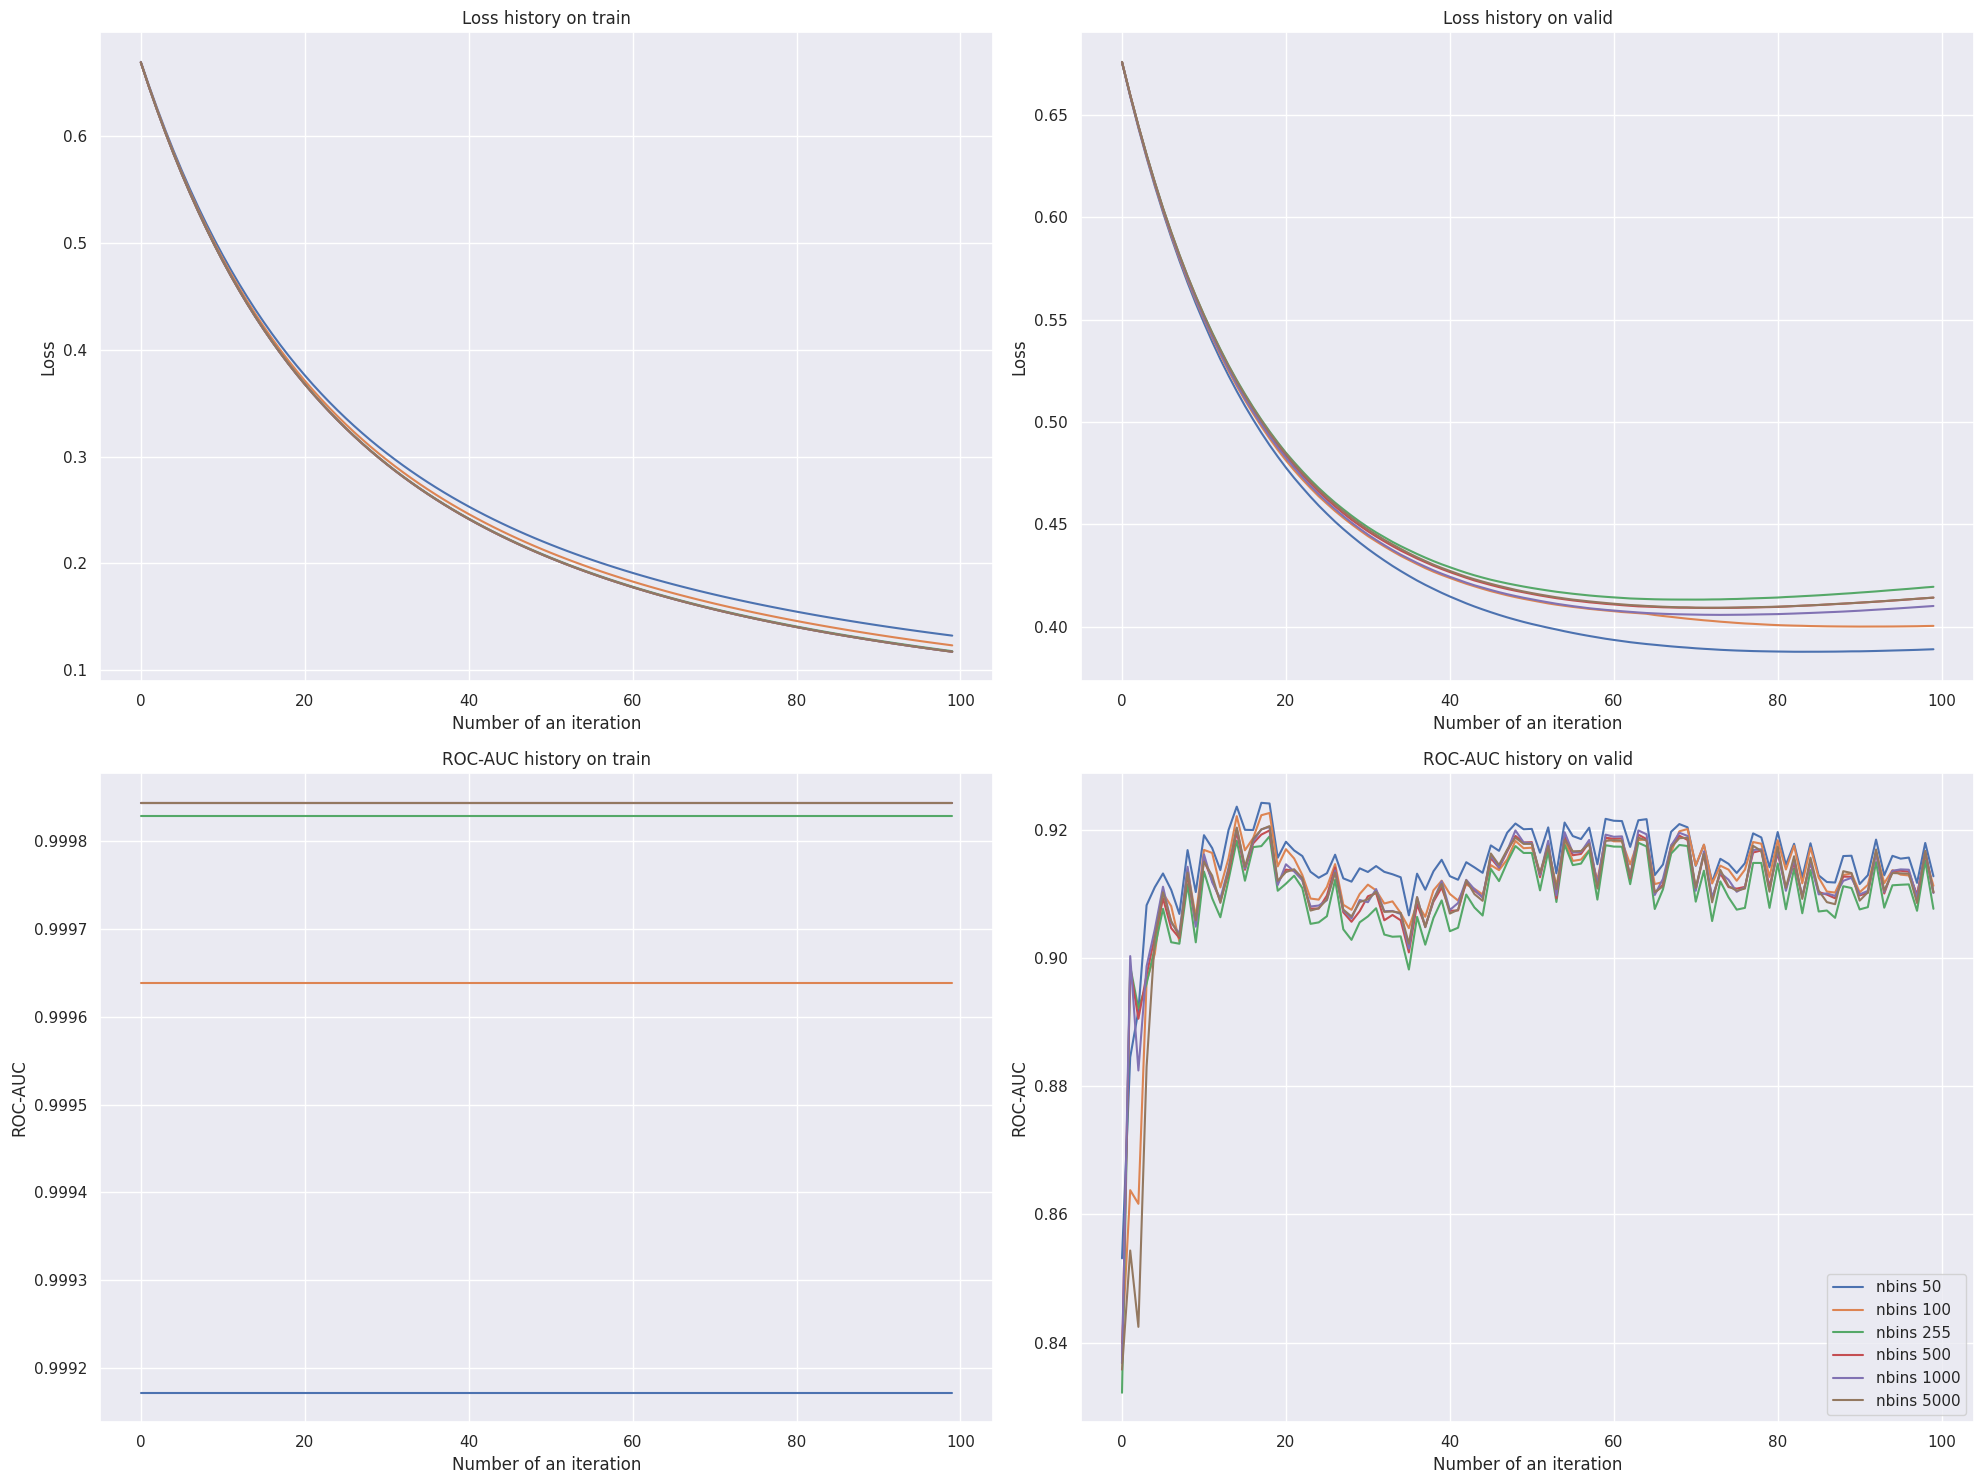

In [21]:
# Quantile
nbins = [50, 100, 255, 500, 1000, 5000]
fig, ax = plt.subplots(figsize=(20, 15), ncols=2, nrows=2)
for num in nbins:
    boosting = Boosting(n_estimators=100, quantization_type = 'Quantile', nbins=num)
    boosting.fit(X_train, y_train, X_valid, y_valid)

    ax[0][0].plot(range(len(boosting.history['train_loss'])), boosting.history['train_loss'], label=f'nbins {num}')
    ax[0][1].plot(range(len(boosting.history['val_loss'])), boosting.history['val_loss'], label=f'nbins {num}')
    ax[0][0].set_xlabel('Number of an iteration')
    ax[0][0].set_ylabel('Loss')
    ax[0][0].set_title('Loss history on train')
    ax[0][1].set_xlabel('Number of an iteration')
    ax[0][1].set_ylabel('Loss')
    ax[0][1].set_title('Loss history on valid')

    ax[1][0].plot(range(len(boosting.history['train_aucroc'])), boosting.history['train_aucroc'], label=f'nbins {num}')
    ax[1][1].plot(range(len(boosting.history['val_aucroc'])), boosting.history['val_aucroc'], label=f'nbins {num}')
    ax[1][0].set_xlabel('Number of an iteration')
    ax[1][0].set_ylabel('ROC-AUC')
    ax[1][0].set_title('ROC-AUC history on train')
    ax[1][1].set_xlabel('Number of an iteration')
    ax[1][1].set_ylabel('ROC-AUC')
    ax[1][1].set_title('ROC-AUC history on valid')
plt.legend()
plt.tight_layout()
plt.show()